### imports

In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss,
    accuracy_score, f1_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

DATA_PATH    = "click_prediction.csv"
MODEL_A_PATH = "add_model_A.json"
MODEL_B_PATH = "add_model_B.json"
TARGET       = "clicked_on_add"

OUTDIR = "outputs_case1"
os.makedirs(OUTDIR, exist_ok=True)

### Load data + split

In [3]:
df = pd.read_csv(DATA_PATH)

drop_cols = [c for c in df.columns if c.endswith("_raw")]   # raw text columns
X = df.drop(columns=[TARGET] + drop_cols)
y = df[TARGET].astype(int)

feature_cols = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Data:", df.shape, "| Train:", X_train.shape, "| Test:", X_test.shape)
print("Base click rate:", y.mean().round(4))

Data: (50000, 36) | Train: (37500, 32) | Test: (12500, 32)
Base click rate: 0.4509


### Load models

In [4]:
mA = XGBClassifier()
mA.load_model(MODEL_A_PATH)

mB = XGBClassifier()
mB.load_model(MODEL_B_PATH)

### Predict once

In [5]:
pA = mA.predict_proba(X_test)[:, 1]
pB = mB.predict_proba(X_test)[:, 1]

yA = (pA >= 0.5).astype(int)
yB = (pB >= 0.5).astype(int)

### Helper functions

In [6]:
def metric_row(name, y_true, p, yhat):
    return {
        "model": name,
        "ROC_AUC": roc_auc_score(y_true, p),
        "Average_Precision": average_precision_score(y_true, p),
        "Log_Loss": log_loss(y_true, p),
        "Accuracy@0.5": accuracy_score(y_true, yhat),
        "F1@0.5": f1_score(y_true, yhat),
    }

def plot_probability_hist(p, title, save_path=None):
    plt.figure(figsize=(7, 4))
    plt.hist(p, bins=30, range=(0, 1), histtype="step", linewidth=2)
    plt.xlabel("Predicted click probability")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def plot_confusion(y_true, yhat, title, save_path=None):
    cm = confusion_matrix(y_true, yhat)
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(cm).plot(values_format="d", colorbar=False)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    return cm

def plot_lift(y_true, y_score, title, save_path=None, n_points=101):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    order = np.argsort(-y_score)
    y_sorted = y_true[order]

    n = len(y_sorted)
    total_pos = y_sorted.sum()
    base_rate = total_pos / n if n > 0 else 0.0

    percs = np.linspace(0, 1, n_points)
    lift = np.zeros_like(percs)
    cum_recall = np.zeros_like(percs)
    cum_pos = np.cumsum(y_sorted)

    for i, frac in enumerate(percs):
        k = max(1, int(np.ceil(frac * n)))
        pos_topk = cum_pos[k - 1]
        rate_topk = pos_topk / k
        lift[i] = (rate_topk / base_rate) if base_rate > 0 else np.nan
        cum_recall[i] = (pos_topk / total_pos) if total_pos > 0 else np.nan

    # Lift plot
    plt.figure(figsize=(7, 4))
    plt.plot(percs, lift, label="Lift")
    plt.axhline(1.0, linestyle="--", color="gray", label="Random (lift=1)")
    plt.xlabel("Proportion of samples targeted (top-k fraction)")
    plt.ylabel("Lift")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return percs, lift, cum_recall

def xgb_weight_importance_from_json(model_path):
    """XGBoost 'weight' importance = #times feature used in splits across all trees."""
    with open(model_path, "r", encoding="utf-8") as f:
        model_json = json.load(f)

    trees = model_json["learner"]["gradient_booster"]["model"]["trees"]
    counts = {}
    for t in trees:
        for j in t.get("split_indices", []):
            if isinstance(j, int) and j >= 0:
                counts[j] = counts.get(j, 0) + 1
    return counts

def to_importance_df(counts, feature_cols, model_label):
    total = sum(counts.values()) if counts else 0
    rows = []
    for i, name in enumerate(feature_cols):
        w = int(counts.get(i, 0))
        rows.append({
            "model": model_label,
            "feature_idx": i,
            "feature": name,
            "weight": w,
            "weight_pct": (w / total * 100.0) if total > 0 else 0.0
        })
    return pd.DataFrame(rows).sort_values("weight", ascending=False)

def plot_feature_importance_bar(imp_df, title, topk=15, save_path=None):
    tmp = imp_df.head(topk).sort_values("weight_pct")
    plt.figure(figsize=(9, 6))
    plt.barh(tmp["feature"], tmp["weight_pct"])
    plt.xlabel("Split usage share (%)")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

### Compute feature importance A/B

In [7]:
impA = to_importance_df(xgb_weight_importance_from_json(MODEL_A_PATH), feature_cols, "A")
impB = to_importance_df(xgb_weight_importance_from_json(MODEL_B_PATH), feature_cols, "B")

# Save tables (optional)
impA.to_csv(os.path.join(OUTDIR, "feature_importance_A_weight.csv"), index=False)
impB.to_csv(os.path.join(OUTDIR, "feature_importance_B_weight.csv"), index=False)

### SECTION A — Show Model A (plots + findings)


MODEL A — RESULTS


,ROC_AUC,Average_Precision,Log_Loss,Accuracy@0.5,F1@0.5
model,,,,,
A,0.7911,0.8096,0.4990,0.7357,0.6272


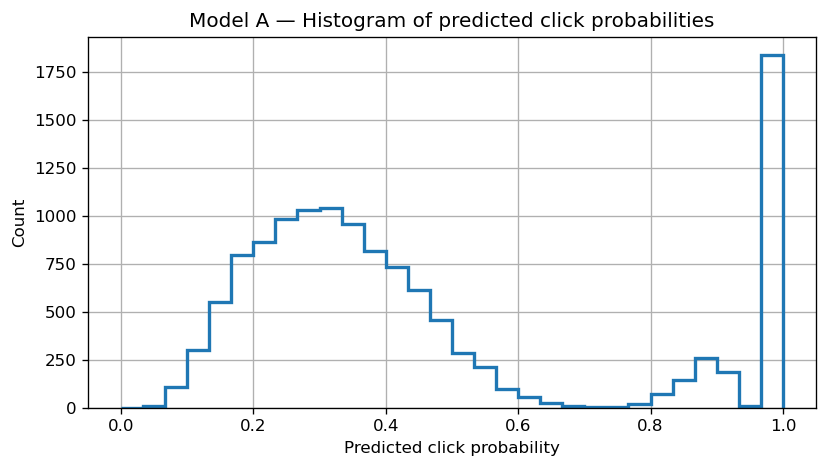

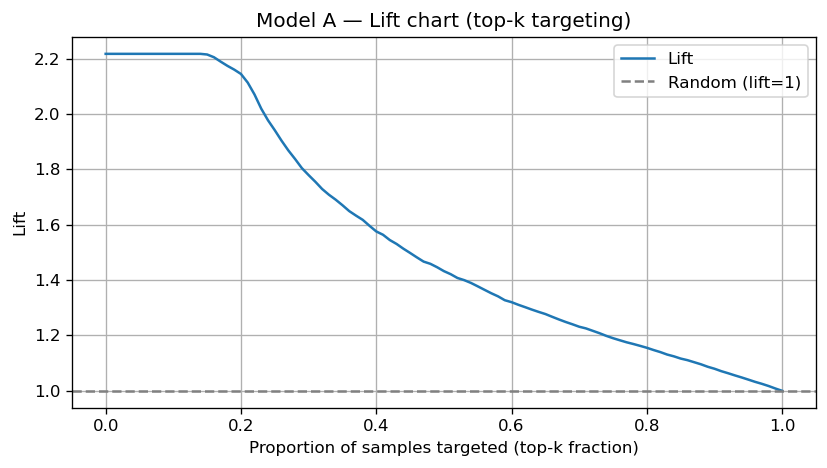

,model,importance_type,feature,value,share_pct
0,A,weight,day_of_year,2787.0,15.197950
1,A,weight,id,2684.0,14.636274
2,A,weight,age,1969.0,10.737267
3,A,weight,time_of_day,1630.0,8.888647
4,A,weight,ad_style_category,947.0,5.164140
5,A,weight,OS,871.0,4.749700
6,A,weight,location,761.0,4.149853
7,A,weight,browser,593.0,3.233722
8,A,weight,device_type,487.0,2.655688
9,A,weight,year,396.0,2.159450


,model,importance_type,feature,value,share_pct
0,A,gain,provided_feedback_about_add,1154.250244,63.075499
1,A,gain,part_of_add_evaluation_focus_group,385.920380,21.089119
2,A,gain,ad_style_category,43.389469,2.371074
3,A,gain,OS,40.296875,2.202075
4,A,gain,device_type,14.365447,0.785018
5,A,gain,purchased_good_5,10.669982,0.583075
6,A,gain,purchased_good_4,10.668561,0.582997
7,A,gain,purchased_good_6,9.877079,0.539746
8,A,gain,purchased_good_1,9.805871,0.535855
9,A,gain,purchased_good_7,9.469531,0.517475


,model,importance_type,feature,value,share_pct
0,A,cover,provided_feedback_about_add,14833.115234,18.820743
1,A,cover,part_of_add_evaluation_focus_group,12567.100586,15.945550
2,A,cover,device_type,3621.628174,4.595241
3,A,cover,ad_style_category,3083.568848,3.912533
4,A,cover,purchased_good_4,2256.950439,2.863693
5,A,cover,purchased_good_5,2204.133789,2.796677
6,A,cover,purchased_good_9,2058.391602,2.611755
7,A,cover,purchased_good_0,2044.557373,2.594202
8,A,cover,purchased_good_6,2001.237671,2.539236
9,A,cover,purchased_good_2,1927.995605,2.446304


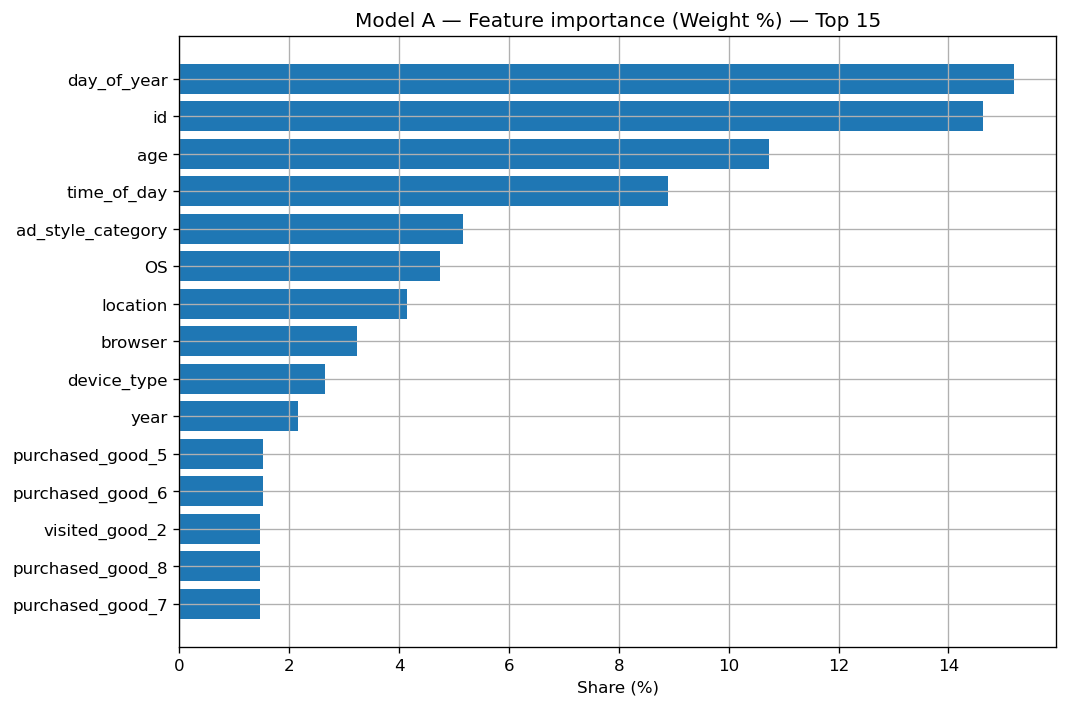

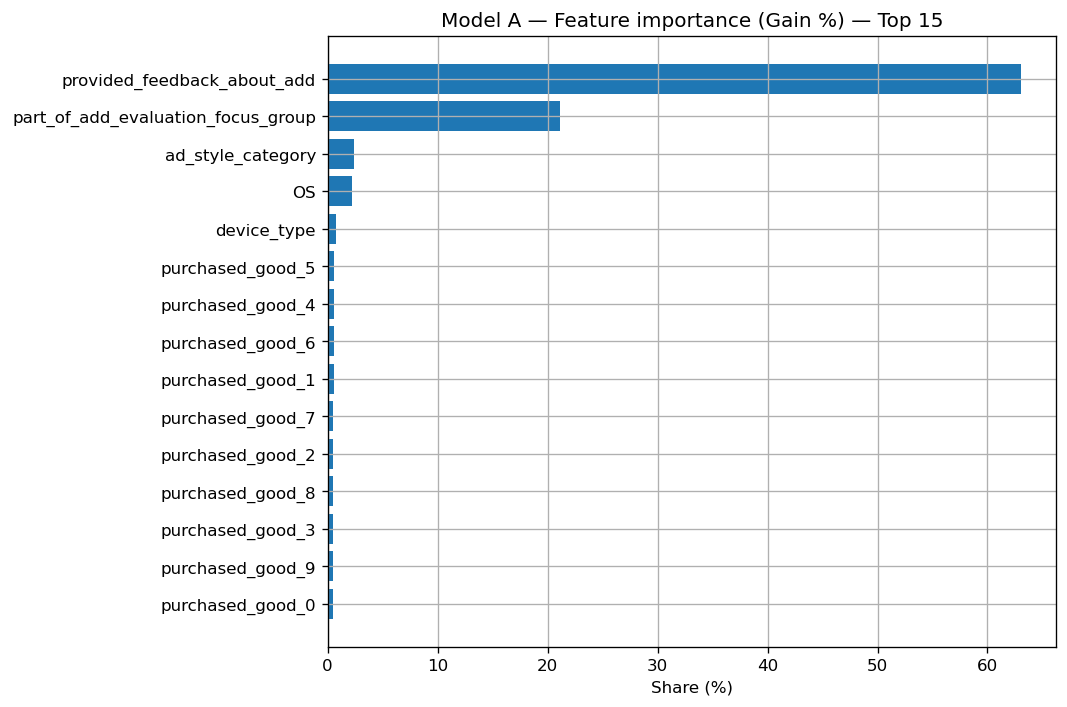

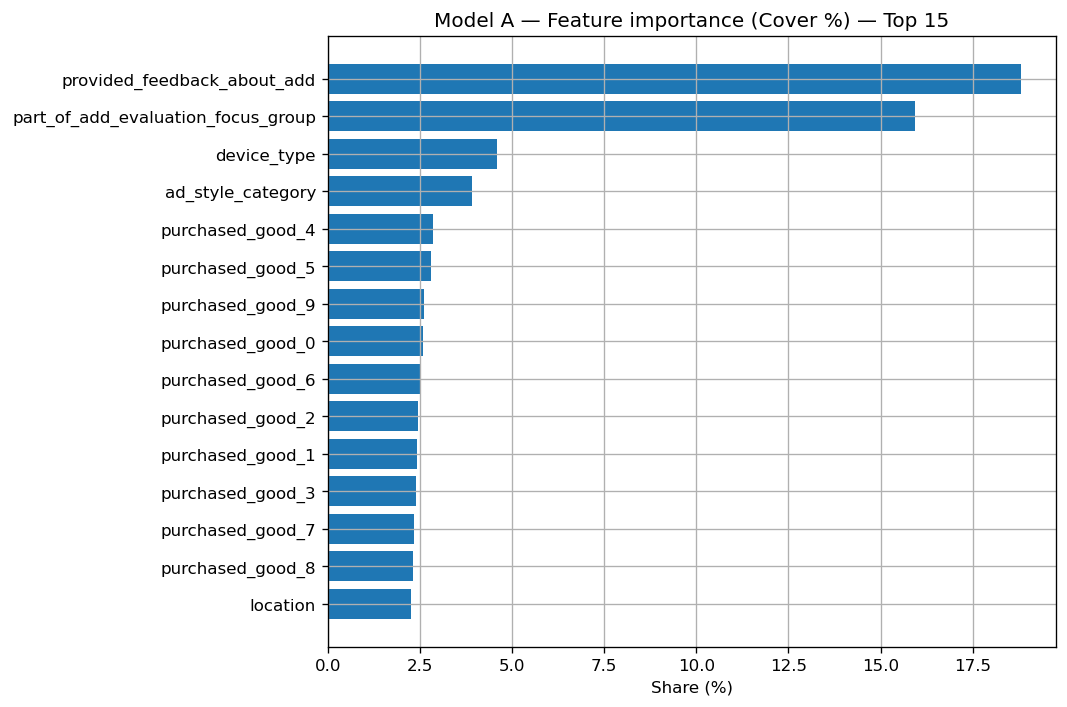

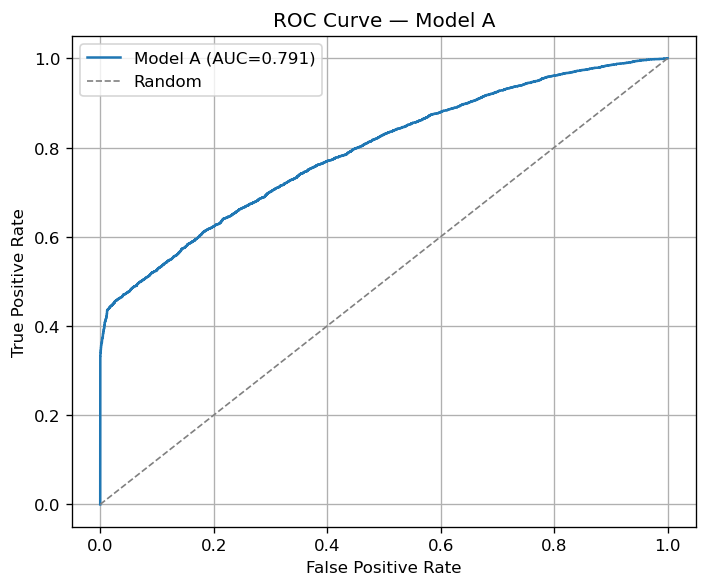

In [8]:
print("\n====================")
print("MODEL A — RESULTS")
print("====================")

metricsA = metric_row("A", y_test, pA, yA)
display(pd.DataFrame([metricsA]).set_index("model").style.format("{:.4f}"))

# --- Predicted probability histogram ---
plot_probability_hist(
    pA,
    "Model A — Histogram of predicted click probabilities",
    save_path=os.path.join(OUTDIR, "A_prob_hist.png")
)

# --- Lift chart (keep if you still want it) ---
plot_lift(
    y_test, pA,
    "Model A — Lift chart (top-k targeting)",
    save_path=os.path.join(OUTDIR, "A_lift.png")
)

# --- XGBoost Feature Importance: Weight + Gain + Cover ---
def xgb_importance_df(model, importance_type: str, feature_cols, model_label: str):
    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    rows = []
    for i, fname in enumerate(feature_cols):
        key = f"f{i}"  # XGBoost internal feature names: f0, f1, ...
        val = float(score.get(key, 0.0))
        rows.append({"model": model_label, "importance_type": importance_type, "feature": fname, "value": val})

    df = pd.DataFrame(rows).sort_values("value", ascending=False).reset_index(drop=True)
    total = df["value"].sum()
    df["share_pct"] = (df["value"] / total * 100.0) if total > 0 else 0.0
    return df

def plot_importance_bar_generic(imp_df, title, topk=15, save_path=None):
    tmp = imp_df.head(topk).copy()

    plt.figure(figsize=(9, 6))
    plt.barh(tmp["feature"][::-1], tmp["share_pct"][::-1])
    plt.xlabel("Share (%)")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

impA_weight = xgb_importance_df(mA, "weight", feature_cols, "A")
impA_gain   = xgb_importance_df(mA, "gain",   feature_cols, "A")
impA_cover  = xgb_importance_df(mA, "cover",  feature_cols, "A")

# Optional: show top tables in notebook
display(impA_weight.head(15))
display(impA_gain.head(15))
display(impA_cover.head(15))

# Save 3 separate plots (Top 15 each)
plot_importance_bar_generic(
    impA_weight,
    "Model A — Feature importance (Weight %) — Top 15",
    topk=15,
    save_path=os.path.join(OUTDIR, "A_feature_importance_weight.png")
)

plot_importance_bar_generic(
    impA_gain,
    "Model A — Feature importance (Gain %) — Top 15",
    topk=15,
    save_path=os.path.join(OUTDIR, "A_feature_importance_gain.png")
)

plot_importance_bar_generic(
    impA_cover,
    "Model A — Feature importance (Cover %) — Top 15",
    topk=15,
    save_path=os.path.join(OUTDIR, "A_feature_importance_cover.png")
)

# --- ROC curve (unchanged) ---
fprA, tprA, _ = roc_curve(y_test, pA)

plt.figure(figsize=(6, 5))
plt.plot(fprA, tprA, label=f"Model A (AUC={metricsA['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model A")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "A_roc.png"), bbox_inches="tight")
plt.show()

### SECTION B — Show Model B (plots + findings)


MODEL B — RESULTS


,ROC_AUC,Average_Precision,Log_Loss,Accuracy@0.5,F1@0.5
model,,,,,
B,0.6478,0.6241,0.6435,0.6135,0.4733


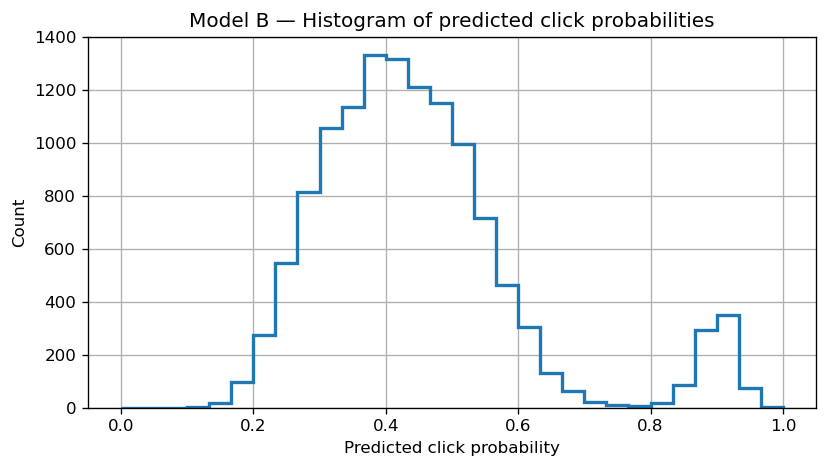

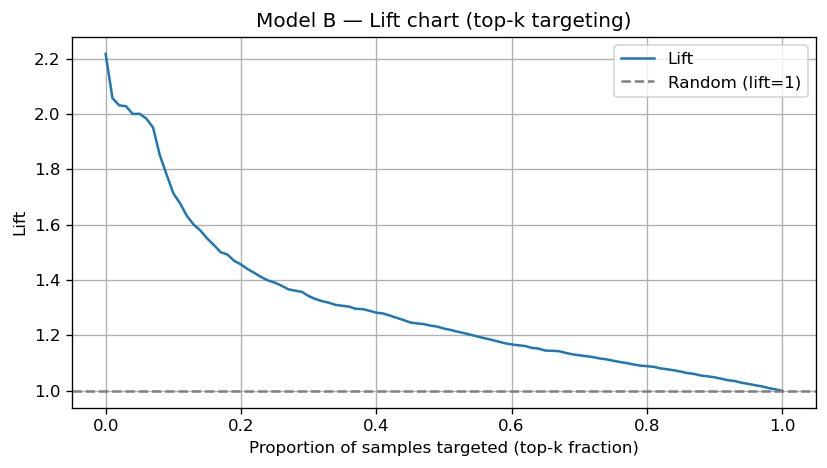

,model,importance_type,feature,value,share_pct
0,B,weight,day_of_year,4648.0,19.056991
1,B,weight,age,3292.0,13.497335
2,B,weight,time_of_day,2601.0,10.664207
3,B,weight,OS,1366.0,5.600656
4,B,weight,ad_style_category,1230.0,5.043050
5,B,weight,location,1222.0,5.010250
6,B,weight,browser,1030.0,4.223042
7,B,weight,device_type,763.0,3.128331
8,B,weight,year,742.0,3.042230
9,B,weight,visited_good_3,433.0,1.775318


,model,importance_type,feature,value,share_pct
0,B,gain,OS,30.097580,15.063812
1,B,gain,ad_style_category,22.264431,11.143328
2,B,gain,device_type,8.422888,4.215648
3,B,gain,purchased_good_9,7.473475,3.740468
4,B,gain,purchased_good_0,7.129377,3.568247
5,B,gain,purchased_good_1,6.976991,3.491978
6,B,gain,purchased_good_5,6.866786,3.436820
7,B,gain,purchased_good_6,6.764691,3.385722
8,B,gain,purchased_good_8,6.617812,3.312209
9,B,gain,purchased_good_2,6.601017,3.303803


,model,importance_type,feature,value,share_pct
0,B,cover,ad_style_category,3184.787109,6.342025
1,B,cover,device_type,2655.895752,5.288817
2,B,cover,purchased_good_6,2277.879883,4.536056
3,B,cover,purchased_good_5,2164.826172,4.310926
4,B,cover,purchased_good_9,2161.245117,4.303795
5,B,cover,day_of_year,2119.418457,4.220503
6,B,cover,purchased_good_0,2094.237549,4.170359
7,B,cover,purchased_good_3,2043.920288,4.070160
8,B,cover,purchased_good_1,1950.764160,3.884654
9,B,cover,purchased_good_4,1937.546997,3.858334


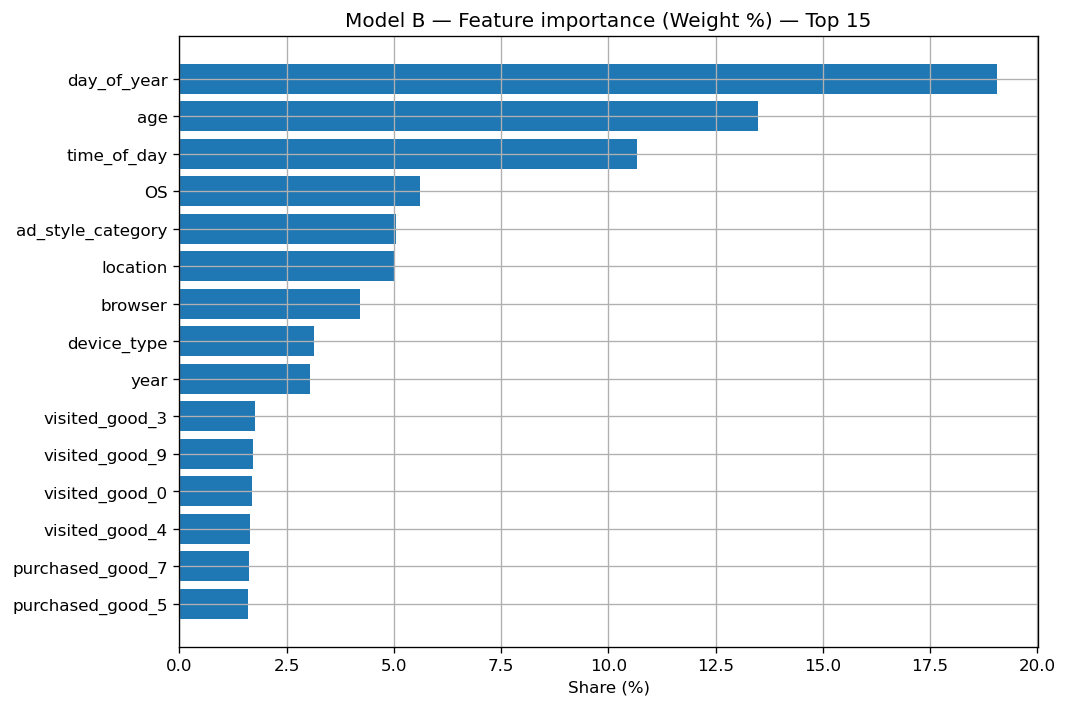

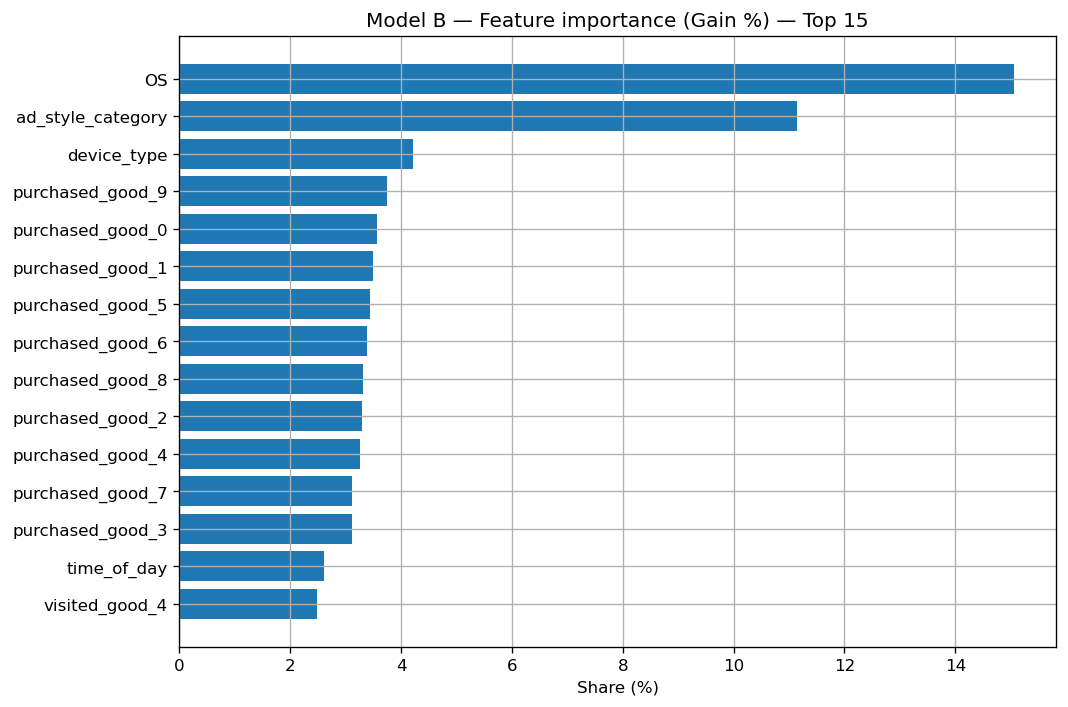

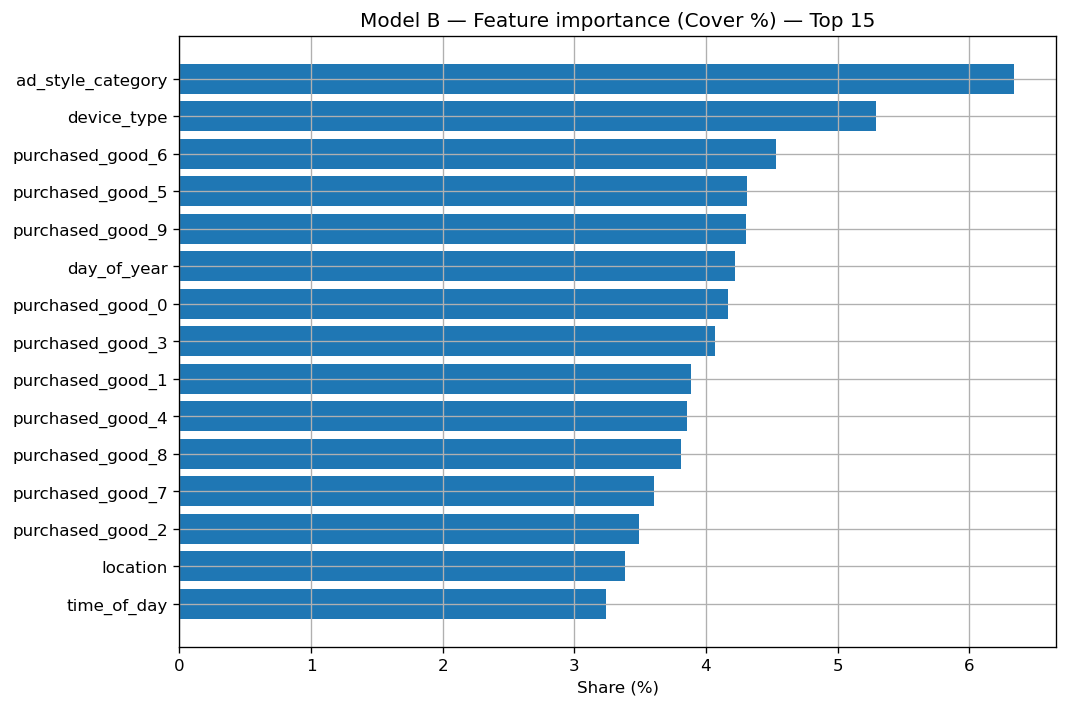

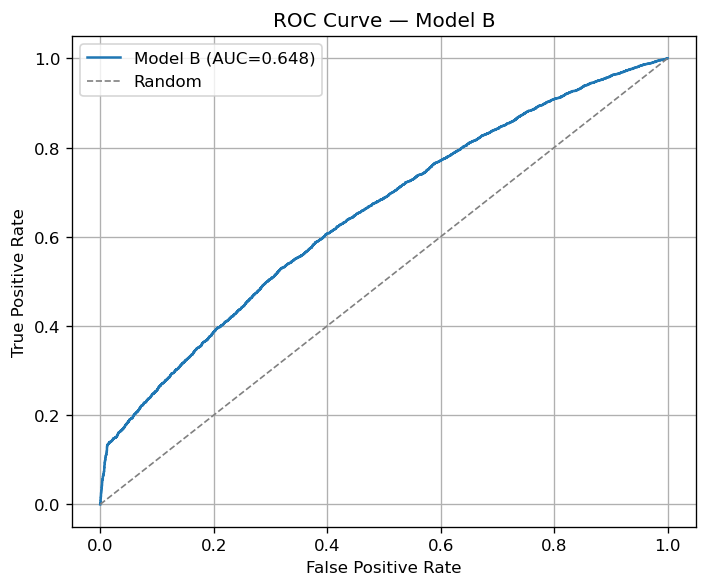

In [9]:
print("\n====================")
print("MODEL B — RESULTS")
print("====================")

metricsB = metric_row("B", y_test, pB, yB)
display(pd.DataFrame([metricsB]).set_index("model").style.format("{:.4f}"))

# --- Predicted probability histogram ---
plot_probability_hist(
    pB,
    "Model B — Histogram of predicted click probabilities",
    save_path=os.path.join(OUTDIR, "B_prob_hist.png")
)

# --- Lift chart (keep if you still want it) ---
plot_lift(
    y_test, pB,
    "Model B — Lift chart (top-k targeting)",
    save_path=os.path.join(OUTDIR, "B_lift.png")
)

# --- XGBoost Feature Importance: Weight + Gain + Cover ---
# (If you already defined these helper functions earlier for Model A,
# you can remove the function definitions here and just reuse them.)

def xgb_importance_df(model, importance_type: str, feature_cols, model_label: str):
    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    rows = []
    for i, fname in enumerate(feature_cols):
        key = f"f{i}"  # XGBoost internal feature names: f0, f1, ...
        val = float(score.get(key, 0.0))
        rows.append({"model": model_label, "importance_type": importance_type, "feature": fname, "value": val})

    df = pd.DataFrame(rows).sort_values("value", ascending=False).reset_index(drop=True)
    total = df["value"].sum()
    df["share_pct"] = (df["value"] / total * 100.0) if total > 0 else 0.0
    return df

def plot_importance_bar_generic(imp_df, title, topk=15, save_path=None):
    tmp = imp_df.head(topk).copy()

    plt.figure(figsize=(9, 6))
    plt.barh(tmp["feature"][::-1], tmp["share_pct"][::-1])
    plt.xlabel("Share (%)")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

impB_weight = xgb_importance_df(mB, "weight", feature_cols, "B")
impB_gain   = xgb_importance_df(mB, "gain",   feature_cols, "B")
impB_cover  = xgb_importance_df(mB, "cover",  feature_cols, "B")

# Optional: show top tables in notebook
display(impB_weight.head(15))
display(impB_gain.head(15))
display(impB_cover.head(15))

# Save 3 separate plots (Top 15 each)
plot_importance_bar_generic(
    impB_weight,
    "Model B — Feature importance (Weight %) — Top 15",
    topk=15,
    save_path=os.path.join(OUTDIR, "B_feature_importance_weight.png")
)

plot_importance_bar_generic(
    impB_gain,
    "Model B — Feature importance (Gain %) — Top 15",
    topk=15,
    save_path=os.path.join(OUTDIR, "B_feature_importance_gain.png")
)

plot_importance_bar_generic(
    impB_cover,
    "Model B — Feature importance (Cover %) — Top 15",
    topk=15,
    save_path=os.path.join(OUTDIR, "B_feature_importance_cover.png")
)

# --- ROC curve (unchanged) ---
fprB, tprB, _ = roc_curve(y_test, pB)

plt.figure(figsize=(6, 5))
plt.plot(fprB, tprB, label=f"Model B (AUC={metricsB['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model B")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "B_roc.png"), bbox_inches="tight")
plt.show()

### SECTION C — Comparison (side-by-side plots)


A vs B — COMPARISON


,ROC_AUC,Average_Precision,Log_Loss,Accuracy@0.5,F1@0.5
model,,,,,
A,0.7911,0.8096,0.4990,0.7357,0.6272
B,0.6478,0.6241,0.6435,0.6135,0.4733


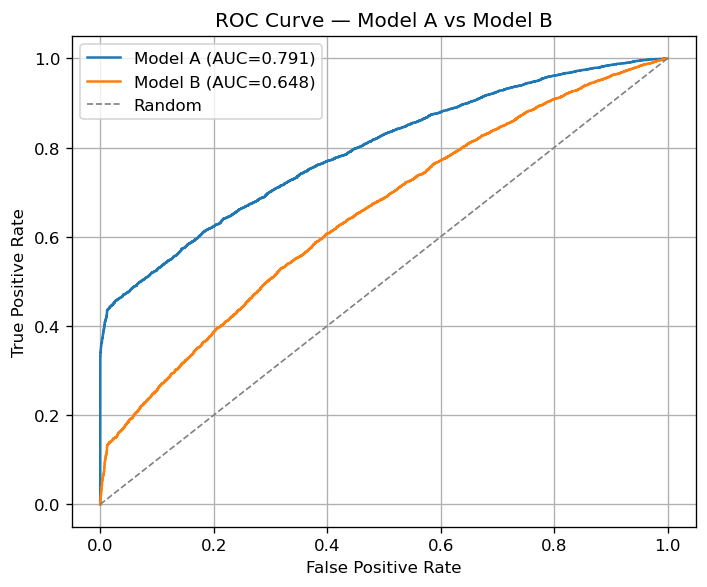

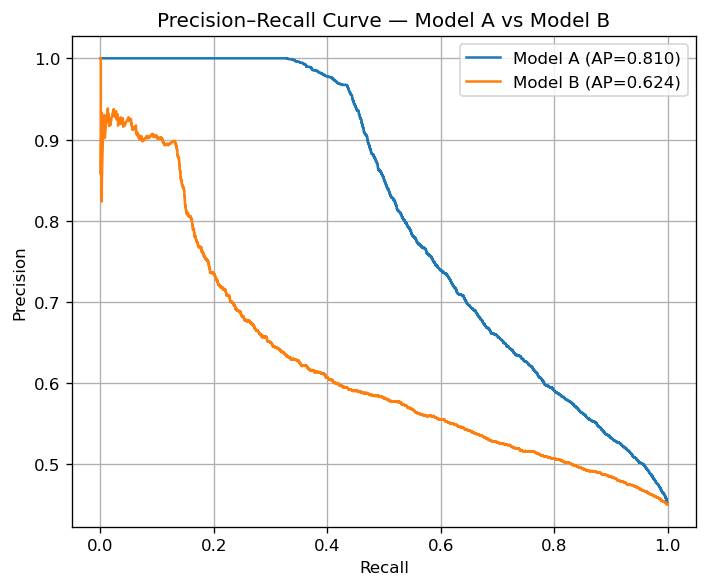

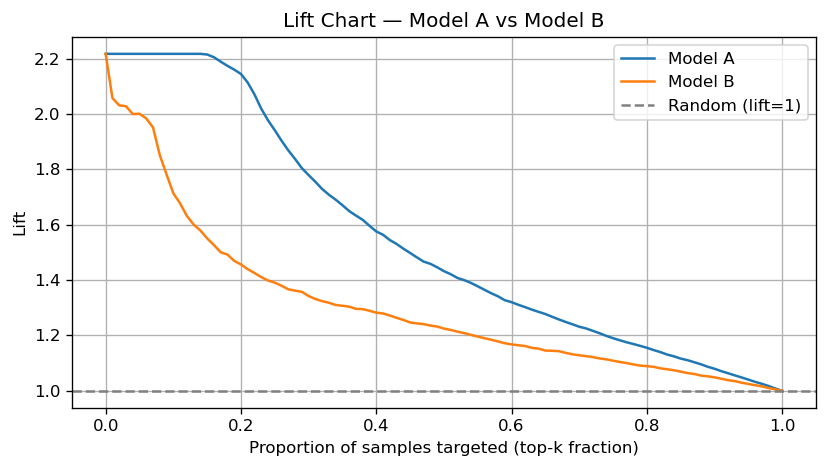

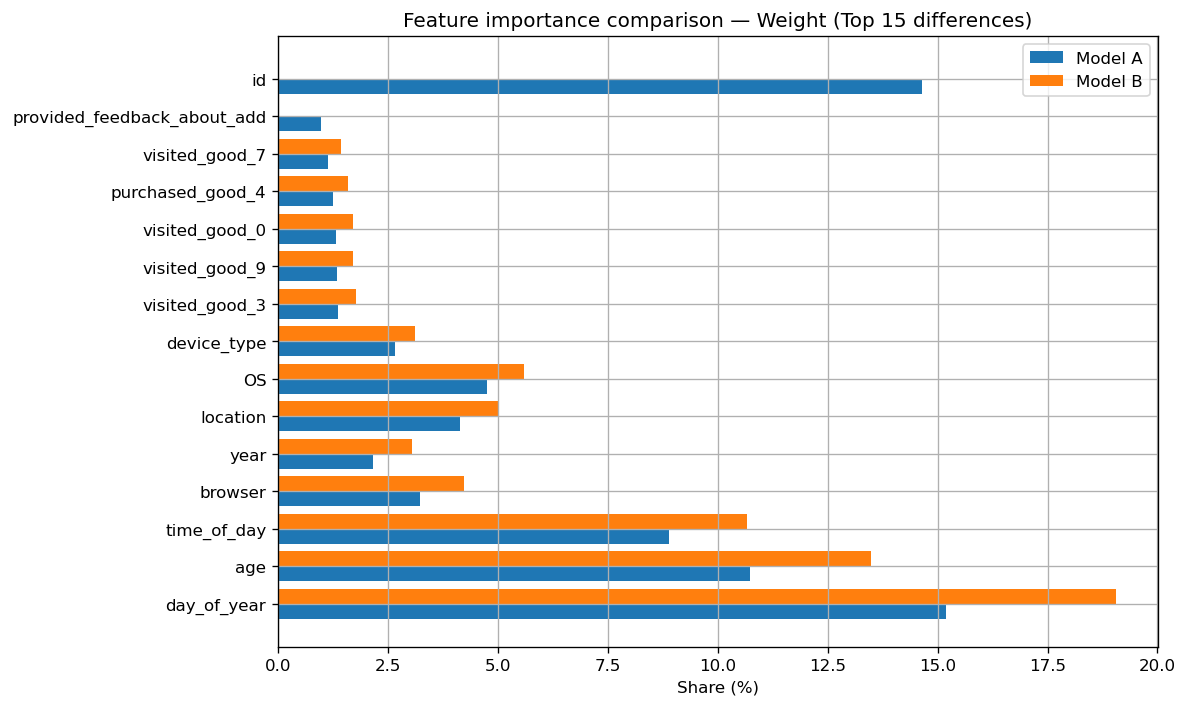

model,feature,A,B,diff_A_minus_B,abs_diff
4,day_of_year,15.197950,19.056991,-3.859041,3.859041
2,age,10.737267,13.497335,-2.760068,2.760068
20,time_of_day,8.888647,10.664207,-1.775560,1.775560
3,browser,3.233722,4.223042,-0.989320,0.989320
31,year,2.159450,3.042230,-0.882780,0.882780
7,location,4.149853,5.010250,-0.860397,0.860397
0,OS,4.749700,5.600656,-0.850956,0.850956
5,device_type,2.655688,3.128331,-0.472644,0.472644
24,visited_good_3,1.357836,1.775318,-0.417482,0.417482
30,visited_good_9,1.341477,1.713817,-0.372340,0.372340


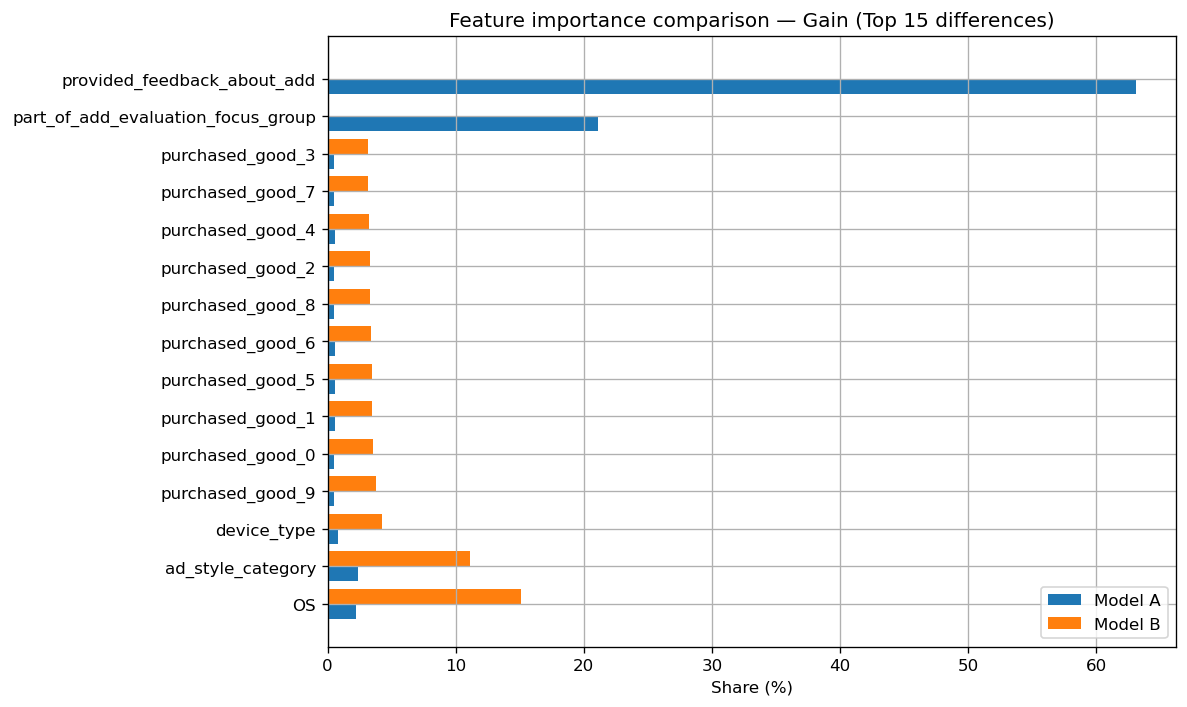

model,feature,A,B,diff_A_minus_B,abs_diff
0,OS,2.202075,15.063812,-12.861737,12.861737
1,ad_style_category,2.371074,11.143328,-8.772254,8.772254
5,device_type,0.785018,4.215648,-3.430629,3.430629
19,purchased_good_9,0.512898,3.740468,-3.227570,3.227570
10,purchased_good_0,0.494854,3.568247,-3.073393,3.073393
11,purchased_good_1,0.535855,3.491978,-2.956123,2.956123
15,purchased_good_5,0.583075,3.436820,-2.853745,2.853745
16,purchased_good_6,0.539746,3.385722,-2.845976,2.845976
18,purchased_good_8,0.516834,3.312209,-2.795375,2.795375
12,purchased_good_2,0.517362,3.303803,-2.786442,2.786442


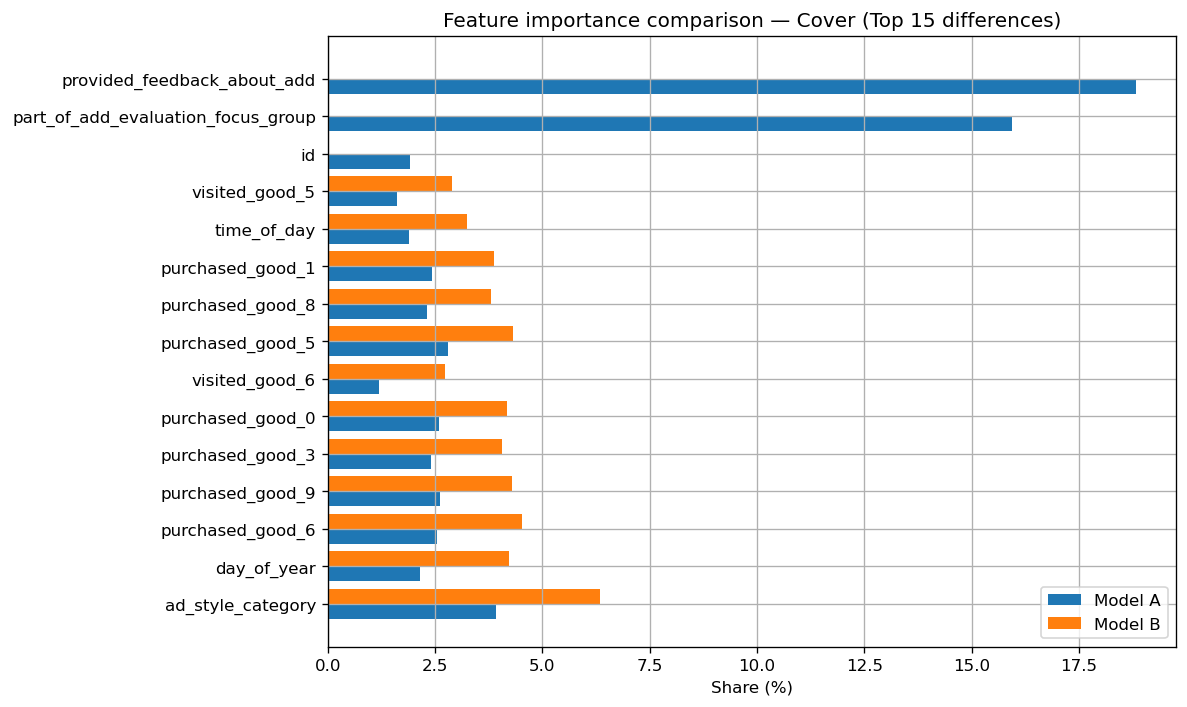

model,feature,A,B,diff_A_minus_B,abs_diff
1,ad_style_category,3.912533,6.342025,-2.429492,2.429492
4,day_of_year,2.161207,4.220503,-2.059297,2.059297
16,purchased_good_6,2.539236,4.536056,-1.996820,1.996820
19,purchased_good_9,2.611755,4.303795,-1.692040,1.692040
13,purchased_good_3,2.401549,4.070160,-1.668612,1.668612
10,purchased_good_0,2.594202,4.170359,-1.576158,1.576158
27,visited_good_6,1.187929,2.722516,-1.534587,1.534587
15,purchased_good_5,2.796677,4.310926,-1.514249,1.514249
18,purchased_good_8,2.317297,3.810882,-1.493585,1.493585
11,purchased_good_1,2.428593,3.884654,-1.456061,1.456061



--- Quick verdict helpers ---
Better by ROC-AUC: A
Better by Lift at top 5%: A
Lift@5%  A=2.22 | B=2.00


In [12]:
print("\n====================")
print("A vs B — COMPARISON")
print("====================")

metrics_df = pd.DataFrame([metricsA, metricsB]).set_index("model")
display(metrics_df.style.format("{:.4f}"))

# 1) ROC overlay
fprA, tprA, _ = roc_curve(y_test, pA)
fprB, tprB, _ = roc_curve(y_test, pB)

plt.figure(figsize=(6, 5))
plt.plot(fprA, tprA, label=f"Model A (AUC={metrics_df.loc['A','ROC_AUC']:.3f})")
plt.plot(fprB, tprB, label=f"Model B (AUC={metrics_df.loc['B','ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model A vs Model B")
plt.legend()
plt.tight_layout()
plt.show()

# 2) PR overlay
precA, recA, _ = precision_recall_curve(y_test, pA)
precB, recB, _ = precision_recall_curve(y_test, pB)

plt.figure(figsize=(6, 5))
plt.plot(recA, precA, label=f"Model A (AP={metrics_df.loc['A','Average_Precision']:.3f})")
plt.plot(recB, precB, label=f"Model B (AP={metrics_df.loc['B','Average_Precision']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Model A vs Model B")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Lift overlay — NO individual lift plots
# Compute lift arrays silently (adapted from your plot_lift helper, but without plotting).
def compute_lift_curve(y_true, y_scores, n_points=101):
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores).astype(float)

    order = np.argsort(-y_scores)
    y_sorted = y_true[order]

    n = len(y_sorted)
    total_pos = y_sorted.sum()
    base_rate = (total_pos / n) if n > 0 else 0.0

    percs = np.linspace(0, 1, n_points)
    lift = np.zeros_like(percs, dtype=float)
    cum_recall = np.zeros_like(percs, dtype=float)

    cum_pos = np.cumsum(y_sorted)

    for i, frac in enumerate(percs):
        k = max(1, int(np.ceil(frac * n)))
        pos_topk = cum_pos[k - 1]
        rate_topk = pos_topk / k
        lift[i] = (rate_topk / base_rate) if base_rate > 0 else np.nan
        cum_recall[i] = (pos_topk / total_pos) if total_pos > 0 else np.nan

    return percs, lift, cum_recall

percsA, liftA, _ = compute_lift_curve(y_test, pA, n_points=101)
percsB, liftB, _ = compute_lift_curve(y_test, pB, n_points=101)

plt.figure(figsize=(7, 4))
plt.plot(percsA, liftA, label="Model A")
plt.plot(percsB, liftB, label="Model B")
plt.axhline(1.0, linestyle="--", color="gray", label="Random (lift=1)")
plt.xlabel("Proportion of samples targeted (top-k fraction)")
plt.ylabel("Lift")
plt.title("Lift Chart — Model A vs Model B")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Feature importance comparison — Weight + Gain + Cover
# Assumes you already created: impA_weight/impA_gain/impA_cover and impB_weight/impB_gain/impB_cover
def compare_importance_topdiff(impA, impB, value_col="share_pct", topk=15):
    wide = (pd.concat([impA[["feature", "model", value_col]],
                       impB[["feature", "model", value_col]]], ignore_index=True)
              .pivot_table(index="feature", columns="model", values=value_col, fill_value=0)
              .reset_index())
    wide["diff_A_minus_B"] = wide["A"] - wide["B"]
    wide["abs_diff"] = wide["diff_A_minus_B"].abs()
    wide_top = (wide.sort_values("abs_diff", ascending=False)
                   .head(topk)
                   .sort_values("diff_A_minus_B"))
    return wide_top

def plot_diff_barh(wide_top, title, xlabel):
    ypos = np.arange(len(wide_top))
    plt.figure(figsize=(10, 6))
    plt.barh(ypos - 0.2, wide_top["A"], height=0.4, label="Model A")
    plt.barh(ypos + 0.2, wide_top["B"], height=0.4, label="Model B")
    plt.yticks(ypos, wide_top["feature"])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

TOPK = 15

wide_w = compare_importance_topdiff(impA_weight, impB_weight, value_col="share_pct", topk=TOPK)
plot_diff_barh(wide_w, f"Feature importance comparison — Weight (Top {TOPK} differences)", "Share (%)")
display(wide_w)

wide_g = compare_importance_topdiff(impA_gain, impB_gain, value_col="share_pct", topk=TOPK)
plot_diff_barh(wide_g, f"Feature importance comparison — Gain (Top {TOPK} differences)", "Share (%)")
display(wide_g)

wide_c = compare_importance_topdiff(impA_cover, impB_cover, value_col="share_pct", topk=TOPK)
plot_diff_barh(wide_c, f"Feature importance comparison — Cover (Top {TOPK} differences)", "Share (%)")
display(wide_c)

# 5) Quick verdict helper (metrics-first, then lift at top 5%)
better_auc = metrics_df["ROC_AUC"].idxmax()

idx5 = 5  # 5% point if percs is linspace(0..1, 101)
better_lift5 = "A" if liftA[idx5] > liftB[idx5] else "B"

print("\n--- Quick verdict helpers ---")
print("Better by ROC-AUC:", better_auc)
print("Better by Lift at top 5%:", better_lift5)
print(f"Lift@5%  A={float(liftA[idx5]):.2f} | B={float(liftB[idx5]):.2f}")

### Conculsion

In [13]:
# 1) Choose business-relevant cutoff for marketing targeting
TOP_FRAC = 0.05  # top 5% of impressions/users

# Robust helper: pick closest point on percs grid
def lift_at_fraction(percs, lift, frac):
    percs = np.asarray(percs)
    lift  = np.asarray(lift)
    idx = int(np.argmin(np.abs(percs - frac)))
    return float(lift[idx])

# Make sure these exist from your comparison cell:
# percsA, liftA = compute_lift_curve(y_test, pA, ...)
# percsB, liftB = compute_lift_curve(y_test, pB, ...)
liftA_k = lift_at_fraction(percsA, liftA, TOP_FRAC)
liftB_k = lift_at_fraction(percsB, liftB, TOP_FRAC)

# 2) Primary decision criteria:
#    - Lift@top-k (higher better)
#    - ROC-AUC (higher better)
#    - Log-loss (lower better)

d_lift = liftA_k - liftB_k
d_auc  = metricsA["ROC_AUC"] - metricsB["ROC_AUC"]
d_ll   = metricsB["Log_Loss"] - metricsA["Log_Loss"]  # positive => A has lower logloss

if abs(d_lift) > 0.02:
    winner = "A" if d_lift > 0 else "B"
    reason = f"higher Lift@top {int(TOP_FRAC*100)}% (A={liftA_k:.2f}, B={liftB_k:.2f})"
elif abs(d_auc) > 0.002:
    winner = "A" if d_auc > 0 else "B"
    reason = f"higher ROC-AUC (A={metricsA['ROC_AUC']:.4f}, B={metricsB['ROC_AUC']:.4f})"
else:
    winner = "A" if metricsA["Log_Loss"] < metricsB["Log_Loss"] else "B"
    reason = f"lower Log-Loss (A={metricsA['Log_Loss']:.4f}, B={metricsB['Log_Loss']:.4f})"

print(f"Model {winner} is better because it has {reason}.")

print("\nKey numbers:")
print(f"Lift@top {int(TOP_FRAC*100)}%:  A={liftA_k:.2f} | B={liftB_k:.2f}")
print(f"ROC-AUC:            A={metricsA['ROC_AUC']:.4f} | B={metricsB['ROC_AUC']:.4f}")
print(f"Average Precision:  A={metricsA['Average_Precision']:.4f} | B={metricsB['Average_Precision']:.4f}")
print(f"Log-Loss:           A={metricsA['Log_Loss']:.4f} | B={metricsB['Log_Loss']:.4f}")
print(f"F1@0.5:             A={metricsA['F1@0.5']:.4f} | B={metricsB['F1@0.5']:.4f}")

Model A is better because it has higher Lift@top 5% (A=2.22, B=2.00).

Key numbers:
Lift@top 5%:  A=2.22 | B=2.00
ROC-AUC:            A=0.7911 | B=0.6478
Average Precision:  A=0.8096 | B=0.6241
Log-Loss:           A=0.4990 | B=0.6435
F1@0.5:             A=0.6272 | B=0.4733
